# Generate figures for animation of SASSIE domain

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import glob
import warnings
from pathlib import Path
import s3fs
from pprint import pprint
import matplotlib
from matplotlib.backends.backend_pdf import PdfPages
from tqdm import tqdm
import cmocean

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:33057")
client

<Client: 'tcp://127.0.0.1:33057' processes=8 threads=32, memory=123.95 GiB>

### Open 3D model fields

In [3]:
# function to open zarr store with a provided s3 bucket path

def open_zarr_store(s3_path):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(anon=False)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

In [4]:
# open SALT zarr store
salt_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/')

# open SEA ICE AREA zarr store
SIarea_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/')

ffmpeg ref: https://trac.ffmpeg.org/wiki/Encode/H.264

To make an animation:

`ffmpeg -r 4 -i figname_%03d.png -pix_fmt yuv420p -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" filename.mp4`

Break each piece down and explain:

`-r 4`: This sets the frame rate to 4 frames per second (fps). This means that the resulting video will play at 4 frames per second.

`-i figname_%03d.png`:

    -i specifies the input files.
    figname_%03d.png is a pattern that FFmpeg uses to match sequentially numbered PNG files.
        %03d tells FFmpeg to look for numbers in the filenames padded to 3 digits (e.g., figname_001.png, figname_002.png, etc.).

`-pix_fmt yuv420p`: This sets the pixel format to yuv420p, which is widely compatible with video players. It stands for:

    Y (luminance/brightness)
    UV (chrominance/color) at 4:2:0 subsampling, meaning lower color resolution, which is common for video compression.

`-vf "scale=trunc(iw/2)*2:trunc(ih/2)*2"`:

    -vf applies a video filter (in this case, the scale filter).
    "scale=trunc(iw/2)*2:trunc(ih/2)*2" resizes the input video to make sure its width (iw) and height (ih) are even numbers.
        trunc(iw/2)*2 ensures the width is divisible by 2 by truncating the division result and multiplying by 2. Similarly for the height.
        Many codecs require the video dimensions to be divisible by 2 for proper encoding.

`filename.mp4`: This is the name of the output file, which will be encoded as an MP4 video.

We want:
- 4 zero padding in filename to number each day sequentially

`ffmpeg -r 10 -i sassie-ecco-salinity_%04d.png -pix_fmt yuv420p -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" -crf 10 sassie-ecco-surface-salinity-2020.mp4`

To make the resolution better and video larger:

`ffmpeg -r 10 -i sassie-ecco-salinity_%04d.png -pix_fmt yuv420p -vf "scale=trunc(iw*2/2)*2:trunc(ih*2/2)*2" -crf 10 sassie-ecco-surface-salinity-2020.mp4`

#### Final notes

- using png with dpi = 300 worked well
- 10 frames per second is good speed
- crf 10 seems like good quality
- can adjust scale depending on what size video you want
- I don't think having the flag `-preset slow` is doing anything noticeable...

`ffmpeg -r 10 -i sassie-ecco-salinity_%04d.png -pix_fmt yuv420p -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" -crf 10 sassie-ecco-surface-salinity-2020.mp4`

## Make figure with SSS and sea ice on top

In [143]:
SIarea_ds = (SIarea_zarr.sel(time='2020-09-15').SIarea*100).load()
salt_ds = salt_zarr.sel(time='2020-09-15').isel(k=0).SALT.load()

In [144]:
# mask out grid cells where sea ice is < 15%
SIarea_over15 = SIarea_ds.where(SIarea_ds>15,np.nan)
# SIarea_over20 = SIarea_ds.where(SIarea_ds>20,np.nan)

In [145]:
# mask out grid cells where sea ice is > 15%
salt_ice_mask = salt_ds.where(SIarea_ds<15,np.nan)
# salt_ice_mask = salt_ds.where(SIarea_ds<20,np.nan)

In [146]:
salt_flip = xr.DataArray(np.rot90(salt_ice_mask.isel(i=slice(450,700),j=slice(0,500),time=0),3), dims=['i','j'])
# si_flip = xr.DataArray(np.rot90(SIarea_over20.isel(i=slice(450,700),j=slice(0,500),time=0),3), dims=['i','j'])
si_flip = xr.DataArray(np.rot90(SIarea_over15.isel(i=slice(450,700),j=slice(0,500),time=0),3), dims=['i','j'])

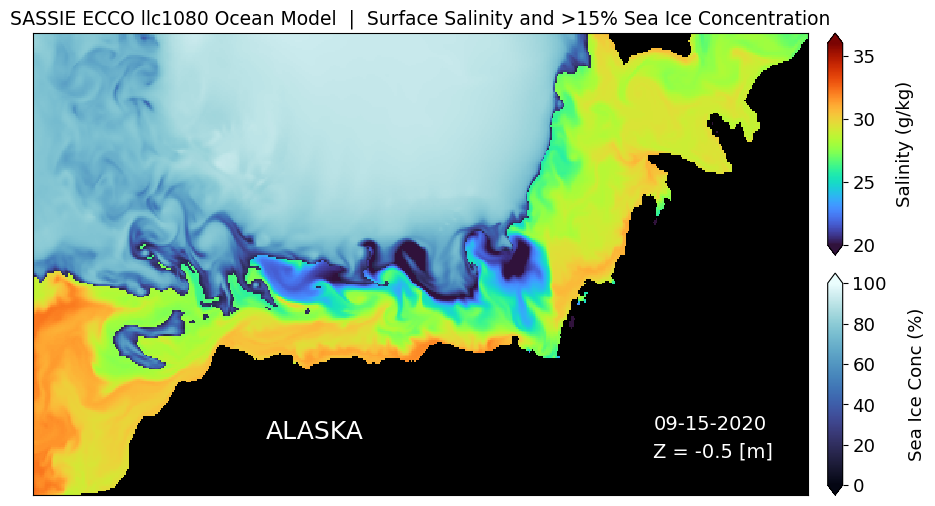

In [132]:
plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(1,1,figsize=[10,6])
salt_cmap = salt_flip.plot(ax=ax,vmin=20,vmax=36,cmap='turbo',add_colorbar=False)
si_cmap = si_flip.plot(ax=ax,vmin=0,vmax=100,cmap=cmocean.cm.ice,add_colorbar=False)
ax.set_title("SASSIE ECCO llc1080 Ocean Model  |  Surface Salinity and >15% Sea Ice Concentration",fontsize=13.5);

# add text for depth
ax.text(400,20,'Z = -0.5 [m]',size=14,color='white')

# add label for Alaska
ax.text(150,30,'ALASKA',size=18, color='white')

# add text for date
date_str = str(salt_ds.time.values)
date = date_str[7:10] + date_str[10:12] + '-' + date_str[2:6]
ax.text(400,35,f'{date}',size=14,color='white')

# make background black
ax.set_facecolor('k')

# remove tick labels
ax.set_xticklabels([])
ax.set_yticklabels([]);
ax.tick_params(left = False, bottom = False) 
ax.set_xlabel("")
ax.set_ylabel("");

# Define the positions of the colorbars (relative to the figure dimensions)
cbar_ax1 = fig.add_axes([0.92, 0.51, 0.015, 0.37])  # [left, bottom, width, height] for the upper colorbar
cbar_ax2 = fig.add_axes([0.92, 0.11, 0.015, 0.37])   # [left, bottom, width, height] for the lower colorbar

# Create the colorbars
cbar1 = fig.colorbar(salt_cmap, cax=cbar_ax1, extend='both')
cbar1.set_label("Salinity (g/kg)", rotation=90, labelpad=15)

cbar2 = fig.colorbar(si_cmap, cax=cbar_ax2, extend='both')
cbar2.set_label("Sea Ice Conc (%)", rotation=90, labelpad=15)

# plt.savefig("tmp.png",dpi=300,bbox_inches='tight')

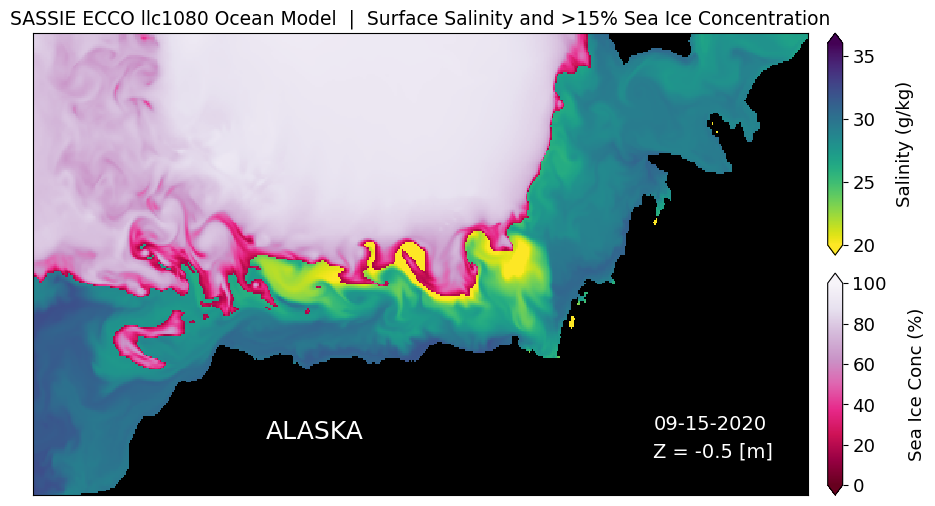

In [148]:
plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(1,1,figsize=[10,6])
salt_cmap = salt_flip.plot(ax=ax,vmin=20,vmax=36,cmap='viridis_r',add_colorbar=False)
si_cmap = si_flip.plot(ax=ax,vmin=0,vmax=100,cmap='PuRd_r',add_colorbar=False)
ax.set_title("SASSIE ECCO llc1080 Ocean Model  |  Surface Salinity and >15% Sea Ice Concentration",fontsize=13.5);

# add text for depth
ax.text(400,20,'Z = -0.5 [m]',size=14,color='white')

# add label for Alaska
ax.text(150,30,'ALASKA',size=18, color='white')

# add text for date
date_str = str(salt_ds.time.values)
date = date_str[7:10] + date_str[10:12] + '-' + date_str[2:6]
ax.text(400,35,f'{date}',size=14,color='white')

# make background black
ax.set_facecolor('k')

# remove tick labels
ax.set_xticklabels([])
ax.set_yticklabels([]);
ax.tick_params(left = False, bottom = False) 
ax.set_xlabel("")
ax.set_ylabel("");

# Define the positions of the colorbars (relative to the figure dimensions)
cbar_ax1 = fig.add_axes([0.92, 0.51, 0.015, 0.37])  # [left, bottom, width, height] for the upper colorbar
cbar_ax2 = fig.add_axes([0.92, 0.11, 0.015, 0.37])   # [left, bottom, width, height] for the lower colorbar

# Create the colorbars
cbar1 = fig.colorbar(salt_cmap, cax=cbar_ax1, extend='both')
cbar1.set_label("Salinity (g/kg)", rotation=90, labelpad=15)

cbar2 = fig.colorbar(si_cmap, cax=cbar_ax2, extend='both')
cbar2.set_label("Sea Ice Conc (%)", rotation=90, labelpad=15)

# plt.savefig("tmp.png",dpi=300,bbox_inches='tight')

***

## Generate series of PNG images, one for each day

In [196]:
time_start = "2019-01-01"
time_end = "2019-12-31"
k_level = 0

In [197]:
seaice_da = SIarea_zarr.sel(time=slice(time_start,time_end)).SIarea*100
salt_da = salt_zarr.sel(time=slice(time_start,time_end)).isel(k=k_level).SALT

In [198]:
# mask out grid cells where sea ice is < 15%
SIarea_over15 = seaice_da.where(seaice_da>15,np.nan)

In [199]:
# mask out grid cells where sea ice is > 20%
salt_ice_mask = salt_da.where(seaice_da<15,np.nan)

In [200]:
# rotate 90 degrees counterclockwise
salt_flip = xr.DataArray(np.rot90(salt_ice_mask.isel(i=slice(450,700),j=slice(0,500)),3,axes=[1,2]), dims=['time','i','j'])
si_flip = xr.DataArray(np.rot90(SIarea_over15.isel(i=slice(450,700),j=slice(0,500)),3,axes=[1,2]), dims=['time','i','j'])

In [201]:
for i in tqdm(range(len(seaice_da.time))):
    
    # pull out one day
    salt_day_da = salt_flip.isel(time=i)
    seaice_day_da = si_flip.isel(time=i)
    
    # make plot
    plt.rcParams.update({'font.size': 13})
    fig, ax = plt.subplots(1,1,figsize=[10,6])
    
    # first colorbar option
    # salt_cmap = salt_day_da.plot(ax=ax,vmin=20,vmax=36,cmap='turbo',add_colorbar=False)
    # si_cmap = seaice_day_da.plot(ax=ax,vmin=0,vmax=100,cmap=cmocean.cm.ice,add_colorbar=False)
    
    # second colorbar option so low SSS and low SI is easier to see
    salt_cmap = salt_day_da.plot(ax=ax,vmin=20,vmax=36,cmap='viridis_r',add_colorbar=False)
    si_cmap = seaice_day_da.plot(ax=ax,vmin=0,vmax=100,cmap='PuRd_r',add_colorbar=False)
    
    ax.set_title("SASSIE ECCO llc1080 Ocean Model  |  Surface Salinity and >15% Sea Ice Concentration",fontsize=13.5);
    
    # add text for depth
    ax.text(400,20,'Z = -0.5 [m]',size=14,color='white')
    
    # add label for Alaska
    ax.text(150,30,'ALASKA',size=18, color='white')
    
    # add text for date
    date_str = str(seaice_da.time[i].values)
    # date = date_str[7:10] + date_str[10:12] + '-' + date_str[2:6]
    date = date_str[5:10] + '-' + date_str[0:4]
    ax.text(400,35,f'{date}',size=14,color='white')
    
    # make background black
    ax.set_facecolor('k')
    
    # remove tick labels
    ax.set_xticklabels([])
    ax.set_yticklabels([]);
    ax.tick_params(left = False, bottom = False) 
    ax.set_xlabel("")
    ax.set_ylabel("");
    
    # Define the positions of the colorbars (relative to the figure dimensions)
    cbar_ax1 = fig.add_axes([0.92, 0.51, 0.015, 0.37])  # [left, bottom, width, height] for the upper colorbar
    cbar_ax2 = fig.add_axes([0.92, 0.11, 0.015, 0.37])   # [left, bottom, width, height] for the lower colorbar
    
    # Create the colorbars
    cbar1 = fig.colorbar(salt_cmap, cax=cbar_ax1, extend='both')
    cbar1.set_label("Salinity (g/kg)", rotation=90, labelpad=15)
    
    cbar2 = fig.colorbar(si_cmap, cax=cbar_ax2, extend='both')
    cbar2.set_label("Sea Ice Concentration (%)", rotation=90, labelpad=15)
    
    # save fig
    filename = f"sassie-ecco-seaice-salinity-beaufort-{date[-4:]}_{i:04d}.png"
    plt.savefig(f"/home/jpluser/efs-mount-point/mzahn/sassie/HH/animation/pngs/{filename}",dpi=300,bbox_inches='tight')
    
    plt.close()
    
    # print(f'. . . saved {filename}')

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 365/365 [05:15<00:00,  1.16it/s]


#### Run in terminal:

For salinity and sea ice movie:
`ffmpeg -r 10 -i sassie-ecco-seaice-salinity-beaufort-2019_%04d.png -pix_fmt yuv420p -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" -crf 10 sassie-ecco-seaice-salinity-beaufort-2019.mp4`

For salinity and sea ice movie:
`ffmpeg -r 10 -i sassie-ecco-seaice-salinity-beaufort-2020_%04d.png -pix_fmt yuv420p -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" -crf 10 sassie-ecco-seaice-salinity-beaufort-2020.mp4`

## transfer to ecco s3 bucket

`aws s3 cp ~/efs-mount-point/mzahn/sassie/HH/animation/pngs/sassie-ecco-seaice-salinity-beaufort-2019.mp4 s3://ecco-processed-data/SASSIE/Videos/`